In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'monospace'

#### Functions

In [3]:
def rms_to_amp(rms):
    return rms * np.sqrt(2)

def lin_to_dB(x):
    return 20 * np.log10(x)

def deg_to_rad(deg):
    return (np.pi / 180) * deg

#### Experiment 1 - plots

In [4]:
# Raw data
df1 = pd.read_csv("bandpass_characterization_data.csv", delimiter=",")

freq = df1["freq_Hz"].to_numpy()
print(freq[-1])
vol_max = df1["Vmax_V"].to_numpy()
vol_min = df1["Vmin_V"].to_numpy()
phase_deg = df1["phase_deg"].to_numpy()

40000.0


In [5]:
# Array conversions
dc_offset = (vol_max + vol_min) / 2
amp = (vol_max - vol_min) / 2
amp_dB = lin_to_dB(amp)
#phase_rad = np.unwrap(deg_to_rad(phase_deg)) # Unwrapped

def phase_unwrapper(phase_deg):
    diffs = np.diff(phase_deg)
    jumps = np.where(np.abs(diffs) > 180)[0]
    unwrapped = phase_deg.copy()
    for jump in jumps:
        if diffs[jump] > 0:
            unwrapped[jump + 1:] -= 360
        else:
            unwrapped[jump + 1:] += 360
    return unwrapped

phase_deg_unwrapped = phase_unwrapper(phase_deg)

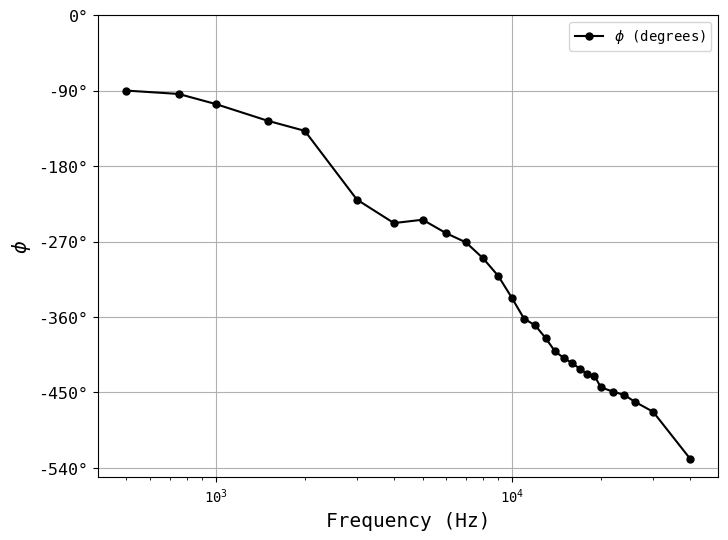

In [6]:

# Plot the phase in degrees, but unwrapped
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(freq, phase_deg_unwrapped, 'o-', ms = 5, color = 'k', label=r'$\phi$ (degrees)')
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=14)
ax.set_ylabel(r'$\phi$', fontsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax.set_yticks(np.arange(-540, 90, 90))
ax.set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=12)

ax.grid(True)
ax.legend()
plt.show()

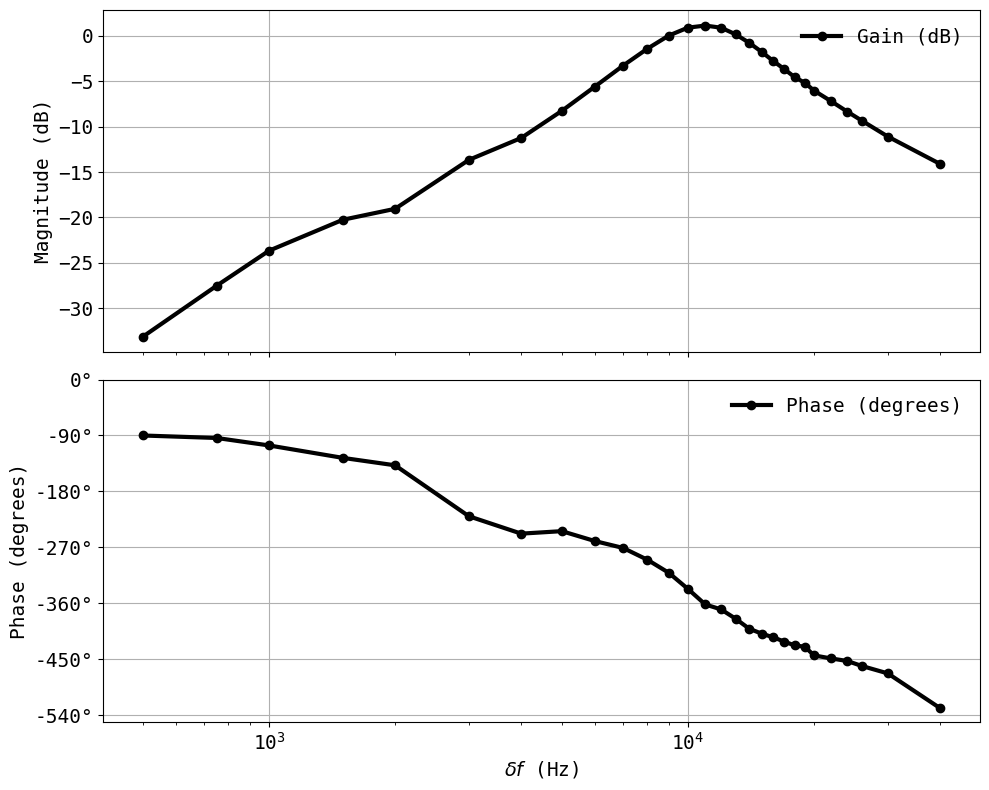

In [7]:
# Plotting amplitude dB

fig, ax = plt.subplots(2,1, figsize=(10, 8), sharex=True)

ax[1].plot(freq, phase_deg_unwrapped, 'o-', linewidth = 3, ms = 6, color = 'k', label=r'Phase (degrees)')
ax[1].set_xscale('log')
#ax[1].set_xlabel('Frequency (Hz)', fontsize=14)
ax[1].set_ylabel(r'Phase (degrees)', fontsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)

#Set yticks to be every 90 degrees, and y-tick labels in degrees
ax[1].set_yticks(np.arange(-540, 90, 90))
ax[1].set_yticklabels([f"{int(tick)}°" for tick in np.arange(-540, 90, 90)], fontsize=14)

ax[1].grid(True)
ax[1].legend(fontsize = 14, frameon = False)

ax[0].plot(freq, amp_dB, 'o-', linewidth = 3, ms = 6, color='k', label = 'Gain (dB)')
ax[1].set_xlabel(r"$\delta f$ (Hz)", fontsize=14)
ax[0].set_ylabel(r"Magnitude (dB)", fontsize=14)
ax[0].set_xscale('log')
ax[0].grid(True)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].legend(fontsize =14, frameon = False)

plt.tight_layout()
plt.show()

In [43]:
def gain_model(f, f_minus, f_plus, G, k):
    num = np.abs(G)*(f/f_minus)**2
    den = ((1+(f/f_minus)**2) * (1+(f/f_plus)**2))
    H = num/den
    return 20 *np.log10(H) + k

In [46]:
y_errs = np.full_like(amp_dB, 0.013*10) # Assuming a constant error of 0.5 dB for all points
#Fit with minuit chi2: 

mfit = cost.LeastSquares(freq[7:-7], amp_dB[7:-7] , y_errs[7:-7], gain_model)
# Initial guesses: f_minus = 1kHz, f_plus = 100kHz, G = 1, k = 0
minuit_bandpass = Minuit(mfit, f_minus=5000, f_plus=15900, G=-1010, k=0)
minuit_bandpass.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1984 (χ²/ndof = 198.4)     │              Nfcn = 897              │
│ EDM = 1.22e+06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           ABOVE call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ f_minus │ 17.318e3  │  0.009e3  │            │            │         │         │       │
│ 1 │ f_plus  │  0.008e6  │  0.012e6  │            │            │         │         │       │
│ 2 │ G       │    -0     │  0.012e6  │            │            │         │         │       │
│ 3 │ k       │    -0     │   2.1e3   │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬─────────────────────────────────────┐
│         │  f_minus   f_plus        G        k │
├─────────┼─────────────────────────────────────┤
│ f_minus │     72.5 106.39e3   8.16e3   1.23e3 │
│  f_plus │ 106.39e3 1.57e+08        0     -0e6 │
│       G │   8.16e3        0 1.53e+08     26e6 │
│       k │   1.23e3     -0e6     26e6 4.43e+06 │
└─────────┴─────────────────────────────────────┘

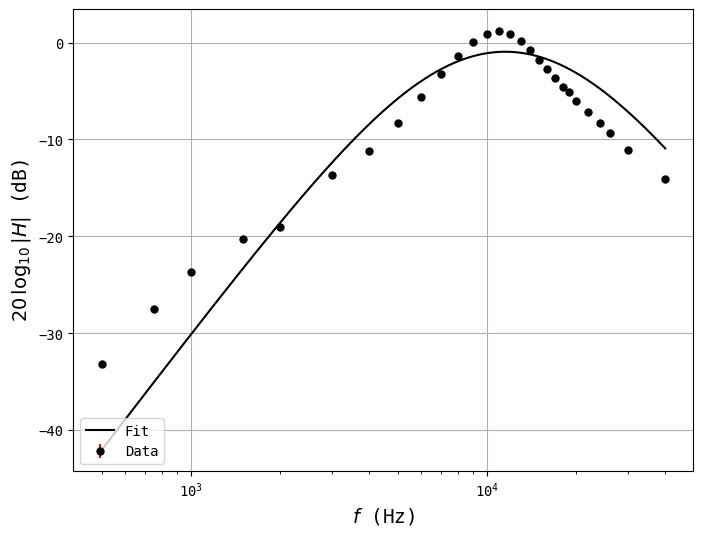

In [47]:
params = minuit_bandpass.values
#plot:
f_linspace = np.linspace(np.min(freq), np.max(freq), 1000)
func_values = gain_model(f_linspace, *params)
plt.figure(figsize=(8, 6))
plt.errorbar(freq, amp_dB, yerr=y_errs, fmt='o', ms = 5, color='k', ecolor='r', label='Data')
plt.plot(f_linspace, func_values, linestyle='-', color='k', label=f'Fit')
#plt.axvline(f_minus, color='r', linestyle='--', label=f'$f_-$ = ({f_minus:.1f} Hz)')
#plt.axvline(f_plus, color='b', linestyle='--', label=f'$f_+$ = ({f_plus:.1f} Hz)')  
plt.xlabel(r"$f$ (Hz)", fontsize=14)
plt.ylabel(r"$20 \,\log_{10}|H|$ (dB)", fontsize=14)
plt.xscale('log')
plt.grid(True)
plt.legend(loc = 'lower left');
